# Random Seed Sensitivity Analysis — Forecast Confidence Levels

Tests whether the choice of random seed significantly affects forecast accuracy for **Load**, **RES**, and **Storage** profiles.  
Forecasts are generated **in-memory only** — no CSV files are written or modified at any point.

**Seeds under test:** `[42, 10, 15, 25, 300, 80]`

| Forecast Type | Columns randomised | Range | Upward bias |
|---|---|---|---|
| Load DA | All load columns | ±5% | ×1.10 |
| Load ID | All load columns | ±2% | none |
| RES DA | Columns whose name contains PV / WP / BM / Hydro | ±35% | none |
| RES ID | All RES columns | ±20% | none |
| Storage DA | Columns whose name contains PV / WP / BM / Hydro | ±35% | none |
| Storage ID | All storage columns | ±20% | none |

The metric throughout is **Mean Absolute Error (MAE)** aggregated to daily means (366 values per seed). Storage actuals can be negative (charge) — MAE is always well-defined for signed values.

## 1. Statistical Background: Tukey Honestly Significant Difference (HSD) Test

Following an omnibus test (Kruskal–Wallis or one-way ANOVA) that indicates at least one significant difference among group means, the **Tukey HSD** procedure identifies *which specific pairs* differ. Developed by John W. Tukey (1949), it balances statistical power with strong control of the **family-wise error rate (FWER)** — the probability of making at least one Type I error across all pairwise comparisons.

### Rationale and Statistical Properties

Tukey HSD controls FWER at α (typically 0.05) for all C(k, 2) pairwise comparisons simultaneously by using the **studentised range distribution** rather than independent t-tests (which would inflate the error rate). The test is appropriate when:
- sample sizes are equal or only moderately unequal,
- group variances are approximately homogeneous (checked via Levene's test),
- data are approximately normally distributed within groups (robust to moderate violations).

### Computational Steps

Given $k$ groups with means $\bar{y}_1, \bar{y}_2, \dots, \bar{y}_k$ and pooled within-group variance $s^2$ (MSE from ANOVA):

**1.** Observed mean difference for each pair $(i,\, j)$:
$$d_{ij} = |\bar{y}_i - \bar{y}_j|$$

**2.** Standard error of the mean difference:
$$SE_{ij} = s\,\sqrt{\frac{1}{n_i} + \frac{1}{n_j}}$$

**3.** Critical value from the studentised range distribution:
$$q^* = q(\alpha,\, k,\, \nu)$$
where $k$ = number of groups and $\nu$ = error degrees of freedom.

**4.** Honestly significant difference (minimum detectable difference):
$$\text{HSD}_{ij} = q^* \times SE_{ij}$$

**5.** Declare pair $(i, j)$ significant if $d_{ij} > \text{HSD}_{ij}$.

**6.** Simultaneous 95 % confidence interval for the true mean difference $\mu_i - \mu_j$:
$$(\bar{y}_i - \bar{y}_j) \;\pm\; \text{HSD}_{ij}$$

The interval is *simultaneous*: the 95 % confidence level applies to the entire family of comparisons.

For unequal sample sizes the **Tukey–Kramer extension** adjusts the SE term (default behaviour in `statsmodels`).

### Implementation in Python (statsmodels)

```python
from statsmodels.stats.multicomp import pairwise_tukeyhsd

result = pairwise_tukeyhsd(endog=df['value'], groups=df['group'], alpha=0.05)
print(result)
```

### Output Table

| Column | Meaning |
|---|---|
| `meandiff` | Mean of group2 − mean of group1 (signed) |
| `p-adj` | Adjusted p-value (FWER-controlled) |
| `lower` / `upper` | Simultaneous 95 % CI bounds |
| `reject` | `True` if CI excludes zero — significant at α |

### Reporting Guidelines
- Always report simultaneous CIs alongside p-values.
- State that FWER is controlled at α = 0.05.
- Include test name, software, and α level.
- With large N (366 days × 6 seeds = 2 190 observations), even tiny practical differences achieve significance. **Report η² (effect size) as the primary evidence for practical significance.**

## 2. Setup

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import warnings
warnings.filterwarnings('ignore')

# ── Seeds under test ──────────────────────────────────────────────────────────
SEEDS = [42, 10, 15, 25, 300, 80]

# ── Forecast randomisation ranges (mirroring data.py) ─────────────────────────
LOAD_DA_RANGE    = (0.95, 1.05)   # ±5%,  10 % upward bias on actuals
LOAD_ID_RANGE    = (0.98, 1.02)   # ±2%
RES_DA_RANGE     = (0.65, 1.35)   # ±35%
RES_ID_RANGE     = (0.80, 1.20)   # ±20%
STORAGE_DA_RANGE = RES_DA_RANGE   # same as RES DA
STORAGE_ID_RANGE = RES_ID_RANGE   # same as RES ID

# ── DA column filter: contains any of these substrings ────────────────────────
RES_KEYWORDS = ['PV', 'WP', 'BM', 'Hydro']

ALPHA           = 0.05
N_BOOT          = 1_000
FORECAST_TYPES  = ['Load DA', 'Load ID', 'RES DA', 'RES ID', 'Storage DA', 'Storage ID']
DATA_DIR        = Path('.')
FIG_DIR         = Path('figures')
FIG_DIR.mkdir(exist_ok=True)

print(f"Seeds          : {SEEDS}")
print(f"Forecast types : {FORECAST_TYPES}")
print(f"α = {ALPHA}  |  Bootstrap resamples = {N_BOOT}")

Seeds          : [42, 10, 15, 25, 300, 80]
Forecast types : ['Load DA', 'Load ID', 'RES DA', 'RES ID', 'Storage DA', 'Storage ID']
α = 0.05  |  Bootstrap resamples = 1000


## 3. Load Actual Data (Read-Only)

The three actual-metering CSVs are loaded read-only. No data is modified or written at any point in this notebook.

In [17]:
load_act = pd.read_csv(DATA_DIR / 'load_actual.csv',    parse_dates=['datetime'], index_col='datetime')
res_act  = pd.read_csv(DATA_DIR / 'res_actual.csv',     parse_dates=['datetime'], index_col='datetime')
stor_act = pd.read_csv(DATA_DIR / 'storage_actual.csv', parse_dates=['datetime'], index_col='datetime')

load_cols = load_act.columns.tolist()
res_cols  = res_act.columns.tolist()
stor_cols = stor_act.columns.tolist()

# DA-filtered subsets: columns whose name contains PV, WP, BM, or Hydro
res_da_cols  = [c for c in res_cols  if any(k in c for k in RES_KEYWORDS)]
stor_da_cols = [c for c in stor_cols if any(k in c for k in RES_KEYWORDS)]

N_STEPS = len(load_act)
N_DAYS  = N_STEPS // 96          # 96 quarter-hours per day

print(f"Load    : {len(load_cols):3d} columns")
print(f"RES     : {len(res_cols):3d} columns  |  DA-filtered : {len(res_da_cols)}")
print(f"Storage : {len(stor_cols):3d} columns  |  DA-filtered : {len(stor_da_cols)}")
print(f"Timesteps : {N_STEPS}  |  Days : {N_DAYS}")
print(f"Period    : {load_act.index[0]}  →  {load_act.index[-1]}")

Load    : 153 columns
RES     :  27 columns  |  DA-filtered : 27
Storage :  16 columns  |  DA-filtered : 16
Timesteps : 35136  |  Days : 366
Period    : 2016-01-01 00:00:00  →  2016-12-31 23:45:00


## 4. In-Memory Forecast Generation

For each seed a fresh `np.random.RandomState` is created and the six forecast types are generated in the same order as `data.py` (`generate_consistent_copies`).  
The per-timestep MAE (averaged across all active columns) is stored immediately and the forecast DataFrames are discarded — peak memory per seed is therefore small.

In [18]:
def make_forecast(actual_df, lo, hi, rng, active_cols, upward_bias=False):
    """
    Generate an in-memory forecast from actual_df.
    Only columns in `active_cols` receive random perturbation.
    No file I/O.  Returns a copy of actual_df with randomised values.
    """
    fc = actual_df.copy()
    for col in active_cols:
        factors = rng.uniform(lo, hi, size=len(fc))
        vals = fc[col].values.astype(float) * factors
        if upward_bias:
            vals *= 1.1
        fc[col] = np.round(vals, 6)
    return fc


def mae_timeseries(actual_df, forecast_df, cols):
    """Per-timestep MAE averaged across `cols`.  Returns 1-D array, length = N_STEPS."""
    a = actual_df[cols].values.astype(float)
    f = forecast_df[cols].values.astype(float)
    return np.abs(a - f).mean(axis=1)


def to_daily(arr):
    """Aggregate per-15-min MAE to daily means.  Returns 1-D array, length = N_DAYS."""
    return arr[: N_DAYS * 96].reshape(N_DAYS, 96).mean(axis=1)


# ── Generate all forecasts and accumulate MAE per seed ────────────────────────
all_mae = {ft: {} for ft in FORECAST_TYPES}

print("Generating in-memory forecasts — no files written ...")
for seed in SEEDS:
    rng = np.random.RandomState(seed)

    # Order matches data.py generate_consistent_copies()
    fc_load_da  = make_forecast(load_act, *LOAD_DA_RANGE,    rng, load_cols,     upward_bias=True)
    fc_load_id  = make_forecast(load_act, *LOAD_ID_RANGE,    rng, load_cols)
    fc_res_da   = make_forecast(res_act,  *RES_DA_RANGE,     rng, res_da_cols)
    fc_res_id   = make_forecast(res_act,  *RES_ID_RANGE,     rng, res_cols)
    fc_stor_da  = make_forecast(stor_act, *STORAGE_DA_RANGE, rng, stor_da_cols)
    fc_stor_id  = make_forecast(stor_act, *STORAGE_ID_RANGE, rng, stor_cols)

    all_mae['Load DA'][seed]    = mae_timeseries(load_act, fc_load_da,  load_cols)
    all_mae['Load ID'][seed]    = mae_timeseries(load_act, fc_load_id,  load_cols)
    all_mae['RES DA'][seed]     = mae_timeseries(res_act,  fc_res_da,   res_da_cols)
    all_mae['RES ID'][seed]     = mae_timeseries(res_act,  fc_res_id,   res_cols)
    all_mae['Storage DA'][seed] = mae_timeseries(stor_act, fc_stor_da,  stor_da_cols)
    all_mae['Storage ID'][seed] = mae_timeseries(stor_act, fc_stor_id,  stor_cols)

    print(f"  seed {seed:>10}  ✓")

print("\n✓ Complete.  No files written.")

Generating in-memory forecasts — no files written ...
  seed         42  ✓
  seed         10  ✓
  seed         15  ✓
  seed         25  ✓
  seed        300  ✓
  seed         80  ✓

✓ Complete.  No files written.


## 5. Forecast Error — 95 % Confidence Intervals

For each seed × forecast-type combination, per-15-min MAE values are aggregated to **daily means** (366 observations per group). Two 95 % CIs on the mean daily MAE are computed:

- **Parametric** — $\bar{x} \pm t_{0.975,\,n-1} \cdot SE$  
- **Bootstrap (percentile)** — 1 000 resamples with replacement

In [19]:
def ci_95(data, n_boot=N_BOOT, boot_seed=42):
    """Return (mean, SE, param_lo, param_hi, boot_lo, boot_hi) for 1-D array `data`."""
    n    = len(data)
    mean = float(data.mean())
    se   = float(data.std(ddof=1) / np.sqrt(n))
    t    = stats.t.ppf(0.975, df=n - 1)
    # Parametric
    p_lo, p_hi = mean - t * se, mean + t * se
    # Bootstrap percentile
    rng   = np.random.RandomState(boot_seed)
    boots = np.array([rng.choice(data, size=n, replace=True).mean() for _ in range(n_boot)])
    b_lo, b_hi = np.percentile(boots, [2.5, 97.5])
    return mean, se, p_lo, p_hi, b_lo, b_hi


rows = []
for ft in FORECAST_TYPES:
    for seed in SEEDS:
        daily = to_daily(all_mae[ft][seed])
        mean, se, pl, pu, bl, bu = ci_95(daily)
        rows.append({
            'Forecast Type':    ft,
            'Seed':             seed,
            'Mean MAE (MWh)':   mean,
            'Std':              daily.std(ddof=1),
            'SE':               se,
            'Param CI Lower':   pl,
            'Param CI Upper':   pu,
            'Boot CI Lower':    bl,
            'Boot CI Upper':    bu,
            'N (days)':         len(daily),
        })

ci_df = pd.DataFrame(rows)
print(f"CI table built: {len(ci_df)} rows  ({len(SEEDS)} seeds × {len(FORECAST_TYPES)} types)")

CI table built: 36 rows  (6 seeds × 6 types)


In [20]:
fmt = '{:.3e}'.format

for ft in FORECAST_TYPES:
    sub = (
        ci_df[ci_df['Forecast Type'] == ft]
        [['Seed', 'Mean MAE (MWh)', 'Std', 'Param CI Lower', 'Param CI Upper',
          'Boot CI Lower', 'Boot CI Upper']]
        .set_index('Seed')
    )
    print(f"\n{'='*72}")
    print(f"  {ft}  —  95 % CI on Daily Mean MAE (MWh)")
    print(f"{'='*72}")
    display(sub.style.format('{:.4e}'))


  Load DA  —  95 % CI on Daily Mean MAE (MWh)


,Mean MAE (MWh),Std,Param CI Lower,Param CI Upper,Boot CI Lower,Boot CI Upper
Seed,,,,,,
42,3.4850e-05,1.5764e-05,3.3230e-05,3.6471e-05,3.3210e-05,3.6497e-05
10,3.4850e-05,1.5761e-05,3.3230e-05,3.6470e-05,3.3216e-05,3.6490e-05
15,3.4893e-05,1.5782e-05,3.3271e-05,3.6516e-05,3.3261e-05,3.6549e-05
25,3.4849e-05,1.5784e-05,3.3227e-05,3.6472e-05,3.3204e-05,3.6482e-05
300,3.4854e-05,1.5776e-05,3.3232e-05,3.6476e-05,3.3216e-05,3.6488e-05
80,3.4894e-05,1.5778e-05,3.3272e-05,3.6515e-05,3.3253e-05,3.6542e-05



  Load ID  —  95 % CI on Daily Mean MAE (MWh)


,Mean MAE (MWh),Std,Param CI Lower,Param CI Upper,Boot CI Lower,Boot CI Upper
Seed,,,,,,
42,3.5029e-06,1.5748e-06,3.3410e-06,3.6648e-06,3.3379e-06,3.6652e-06
10,3.5030e-06,1.5748e-06,3.3411e-06,3.6648e-06,3.3389e-06,3.6679e-06
15,3.5028e-06,1.5747e-06,3.3409e-06,3.6646e-06,3.3364e-06,3.6656e-06
25,3.4990e-06,1.5682e-06,3.3378e-06,3.6602e-06,3.3343e-06,3.6623e-06
300,3.5001e-06,1.5699e-06,3.3387e-06,3.6615e-06,3.3377e-06,3.6630e-06
80,3.4981e-06,1.5738e-06,3.3364e-06,3.6599e-06,3.3334e-06,3.6607e-06



  RES DA  —  95 % CI on Daily Mean MAE (MWh)


...

,Mean MAE (MWh),Std,Param CI Lower,Param CI Upper,Boot CI Lower,Boot CI Upper
Seed,,,,,,
42,6.9894e-05,4.4612e-05,6.5309e-05,7.4480e-05,6.5385e-05,7.4570e-05
10,6.9438e-05,4.4156e-05,6.4900e-05,7.3977e-05,6.4925e-05,7.4049e-05
15,6.9408e-05,4.4127e-05,6.4872e-05,7.3944e-05,6.4912e-05,7.3963e-05
25,6.9706e-05,4.4344e-05,6.5148e-05,7.4265e-05,6.5269e-05,7.4320e-05
300,6.9494e-05,4.4233e-05,6.4948e-05,7.4041e-05,6.5051e-05,7.4090e-05
80,6.9657e-05,4.4393e-05,6.5094e-05,7.4221e-05,6.5248e-05,7.4269e-05



  Storage DA  —  95 % CI on Daily Mean MAE (MWh)


,Mean MAE (MWh),Std,Param CI Lower,Param CI Upper,Boot CI Lower,Boot CI Upper
Seed,,,,,,
42,7.4018e-05,4.5927e-05,6.9297e-05,7.8739e-05,6.9372e-05,7.8836e-05
10,7.3870e-05,4.5921e-05,6.9150e-05,7.8590e-05,6.9151e-05,7.8681e-05
15,7.3965e-05,4.6052e-05,6.9231e-05,7.8698e-05,6.9231e-05,7.8760e-05
25,7.4132e-05,4.6070e-05,6.9396e-05,7.8868e-05,6.9404e-05,7.9057e-05
300,7.4197e-05,4.6259e-05,6.9442e-05,7.8951e-05,6.9535e-05,7.9095e-05
80,7.4085e-05,4.6016e-05,6.9355e-05,7.8815e-05,6.9352e-05,7.8986e-05



  Storage ID  —  95 % CI on Daily Mean MAE (MWh)


,Mean MAE (MWh),Std,Param CI Lower,Param CI Upper,Boot CI Lower,Boot CI Upper
Seed,,,,,,
42,4.2231e-05,2.6180e-05,3.9540e-05,4.4922e-05,3.9540e-05,4.4976e-05
10,4.2246e-05,2.6257e-05,3.9547e-05,4.4945e-05,3.9578e-05,4.5036e-05
15,4.2313e-05,2.6323e-05,3.9607e-05,4.5018e-05,3.9657e-05,4.5088e-05
25,4.2341e-05,2.6432e-05,3.9624e-05,4.5058e-05,3.9644e-05,4.5090e-05
300,4.2437e-05,2.6490e-05,3.9714e-05,4.5160e-05,3.9751e-05,4.5253e-05
80,4.2309e-05,2.6301e-05,3.9606e-05,4.5013e-05,3.9674e-05,4.5082e-05


## 6. Assumption Check — Levene's Test for Variance Homogeneity

Tukey HSD assumes approximately equal within-group variances.  
Levene's test (median-centred, robust to non-normality) checks H₀: all seeds have equal variance in daily MAE.

In [21]:
print("Levene's Test for Variance Homogeneity  (median-centred)")
print("H₀: all seeds have equal variance in daily MAE")
print("─" * 72)

lev_results = {}
for ft in FORECAST_TYPES:
    grps = [to_daily(all_mae[ft][s]) for s in SEEDS]
    W, p = stats.levene(*grps, center='median')
    lev_results[ft] = {'W': W, 'p': p}
    verdict = '✓ Homogeneous  (p ≥ 0.05)' if p >= ALPHA else '✗ Heterogeneous (p < 0.05)'
    print(f"  {ft:<16}: W = {W:9.4f},  p = {p:.3e}  →  {verdict}")

print("\nNote: Heterogeneous variances do not invalidate the test at the sample")
print("sizes used here, but consider the Games–Howell test as a robustness check.")

Levene's Test for Variance Homogeneity  (median-centred)
H₀: all seeds have equal variance in daily MAE
────────────────────────────────────────────────────────────────────────
  Load DA         : W =    0.0009,  p = 1.000e+00  →  ✓ Homogeneous  (p ≥ 0.05)
  Load ID         : W =    0.0041,  p = 1.000e+00  →  ✓ Homogeneous  (p ≥ 0.05)
  RES DA          : W =    0.0026,  p = 1.000e+00  →  ✓ Homogeneous  (p ≥ 0.05)
  RES ID          : W =    0.0121,  p = 1.000e+00  →  ✓ Homogeneous  (p ≥ 0.05)
  Storage DA      : W =    0.0033,  p = 1.000e+00  →  ✓ Homogeneous  (p ≥ 0.05)
  Storage ID      : W =    0.0091,  p = 1.000e+00  →  ✓ Homogeneous  (p ≥ 0.05)

Note: Heterogeneous variances do not invalidate the test at the sample
sizes used here, but consider the Games–Howell test as a robustness check.


## 7. Omnibus Test — Kruskal–Wallis

The **Kruskal–Wallis H test** (non-parametric one-way ANOVA on ranks) tests whether all six seed groups share the same daily-MAE distribution.  
H₀: the distributions are identical across seeds.

Effect size η² is computed as:
$$\eta^2 = \frac{H - k + 1}{n_{\text{total}} - k}$$

In [ ]:
print("Kruskal–Wallis H Test  (non-parametric omnibus)")
print("H₀: all seeds share the same distribution of daily MAE")
print("─" * 72)

kw_results = {}
for ft in FORECAST_TYPES:
    grps    = [to_daily(all_mae[ft][s]) for s in SEEDS]
    n_total = sum(len(g) for g in grps)
    k       = len(grps)
    H, p    = stats.kruskal(*grps)
    eta2    = max(0.0, (H - k + 1) / (n_total - k))
    kw_results[ft] = {'H': H, 'p': p, 'eta2': eta2}
    verdict = '✓ Significant' if p < ALPHA else '✗ Not significant'
    print(f"  {ft:<16}: H = {H:9.4f},  p = {p:.3e},  η² = {eta2:.5f}  →  {verdict}")

print("\nN = 366 days × 6 seeds = 2190 → large N inflates power: examine η², not just p.")

Kruskal–Wallis H Test  (non-parametric omnibus)
H₀: all seeds share the same distribution of daily MAE
────────────────────────────────────────────────────────────────────────
  Load DA         : H =    0.0054,  p = 1.000e+00,  η² = 0.00000  →  ✗ Not significant
  Load ID         : H =    0.0054,  p = 1.000e+00,  η² = 0.00000  →  ✗ Not significant
  RES DA          : H =    0.0071,  p = 1.000e+00,  η² = 0.00000  →  ✗ Not significant
  RES ID          : H =    0.0259,  p = 1.000e+00,  η² = 0.00000  →  ✗ Not significant
  Storage DA      : H =    0.0071,  p = 1.000e+00,  η² = 0.00000  →  ✗ Not significant
  Storage ID      : H =    0.0062,  p = 1.000e+00,  η² = 0.00000  →  ✗ Not significant

η² benchmarks:  small ≥ 0.01  |  medium ≥ 0.06  |  large ≥ 0.14
N = 366 days × 6 seeds = 2190 → large N inflates power: examine η², not just p.


## 8. Post-Hoc: Tukey HSD Pairwise Comparisons

A separate Tukey HSD test is run for each of the six forecast types.  
Each test evaluates C(6, 2) = **15 pairwise comparisons** with FWER controlled at α = 0.05.  
`pairwise_tukeyhsd` from `statsmodels` applies the Tukey–Kramer extension automatically for unequal group sizes.

In [23]:
print("Tukey HSD Post-Hoc  (α = 0.05, FWER controlled)")
print("=" * 72)

tukey_results = {}
for ft in FORECAST_TYPES:
    print(f"\n── {ft} ──")
    values = np.concatenate([to_daily(all_mae[ft][s]) for s in SEEDS])
    labels = np.concatenate([[str(s)] * N_DAYS for s in SEEDS])

    res = pairwise_tukeyhsd(endog=values, groups=labels, alpha=ALPHA)
    tukey_results[ft] = res
    print(res)

    tbl   = pd.DataFrame(data=res._results_table.data[1:], columns=res._results_table.data[0])
    n_sig = int((tbl['reject'] == True).sum())
    print(f"  → {n_sig} / {len(tbl)} pairs significantly different at α = {ALPHA}")

Tukey HSD Post-Hoc  (α = 0.05, FWER controlled)

── Load DA ──


Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj lower upper reject
-----------------------------------------------
    10     15      0.0   1.0  -0.0   0.0  False
    10     25     -0.0   1.0  -0.0   0.0  False
    10    300      0.0   1.0  -0.0   0.0  False
    10     42      0.0   1.0  -0.0   0.0  False
    10     80      0.0   1.0  -0.0   0.0  False
    15     25     -0.0   1.0  -0.0   0.0  False
    15    300     -0.0   1.0  -0.0   0.0  False
    15     42     -0.0   1.0  -0.0   0.0  False
    15     80      0.0   1.0  -0.0   0.0  False
    25    300      0.0   1.0  -0.0   0.0  False
    25     42      0.0   1.0  -0.0   0.0  False
    25     80      0.0   1.0  -0.0   0.0  False
   300     42     -0.0   1.0  -0.0   0.0  False
   300     80      0.0   1.0  -0.0   0.0  False
    42     80      0.0   1.0  -0.0   0.0  False
-----------------------------------------------
  → 0 / 15 pairs significantly different at α = 0.05

── Load ID ──
Multiple Compari

## 9. Visualisations

### 9a — Daily MAE Distributions by Seed (Box Plots)

Each box summarises the distribution of the 366 daily mean MAE values for one seed.  
The Kruskal–Wallis result and η² are annotated in each panel.

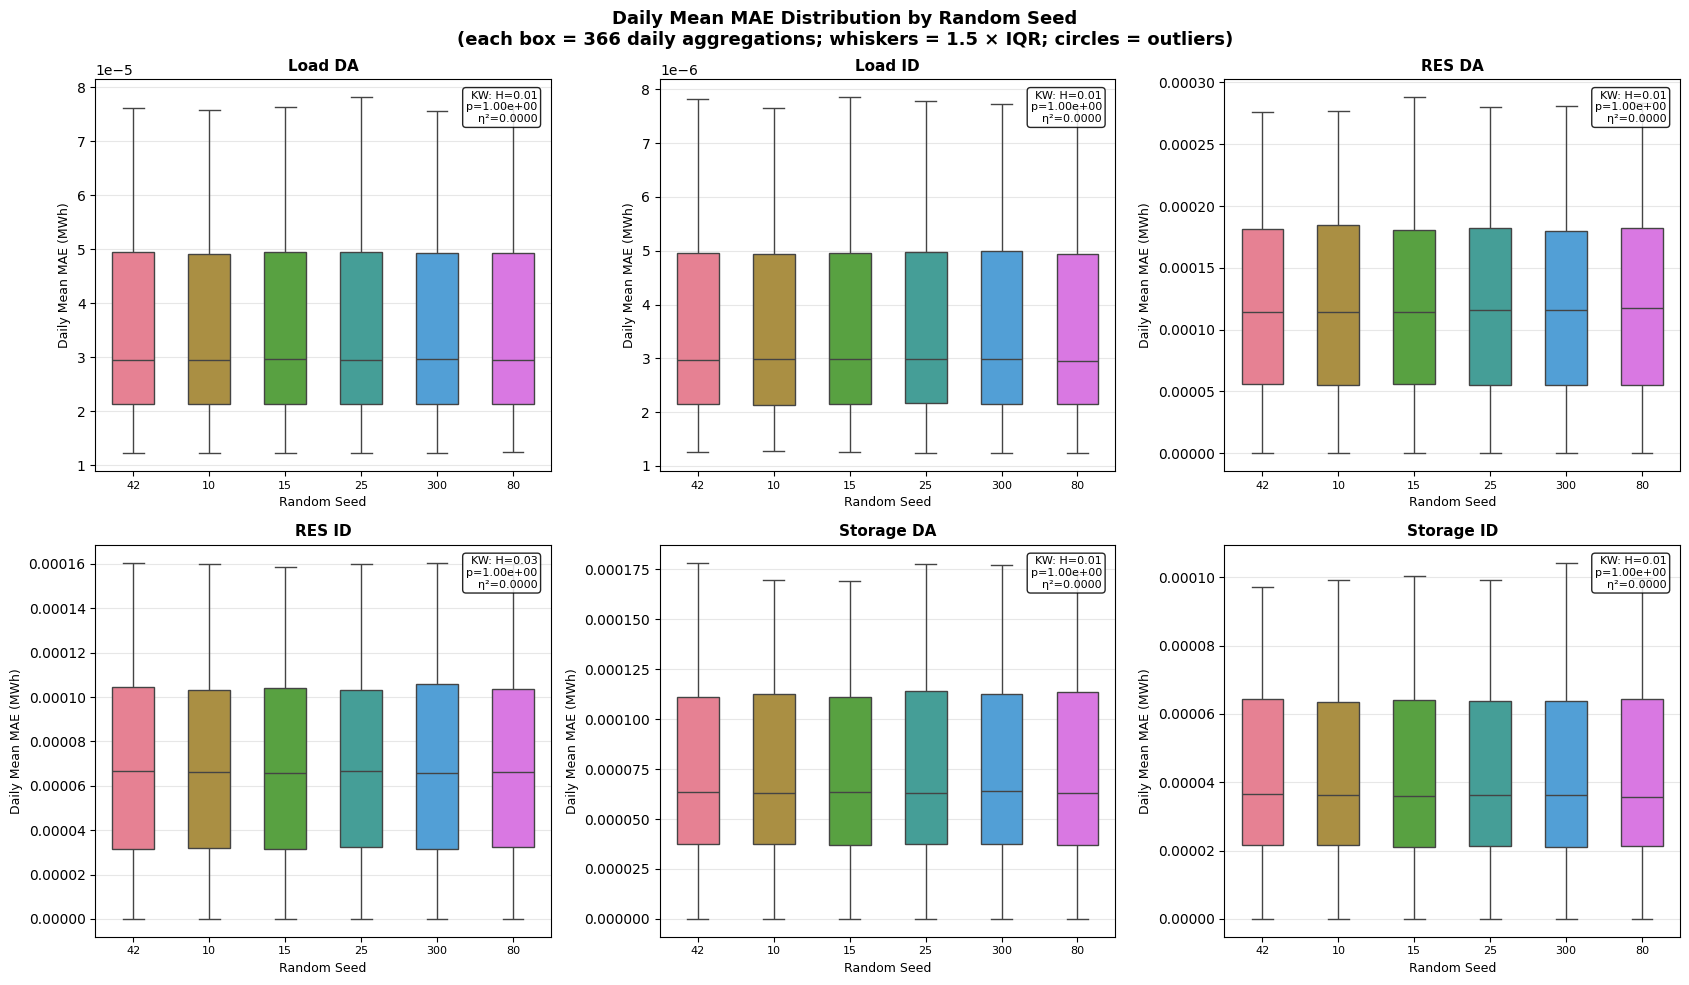

In [24]:
palette = sns.color_palette("husl", len(SEEDS))
seed_order = [str(s) for s in SEEDS]

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
for ax, ft in zip(axes.flat, FORECAST_TYPES):
    rows = [
        {'Seed': str(s), 'Daily Mean MAE (MWh)': v}
        for s in SEEDS
        for v in to_daily(all_mae[ft][s])
    ]
    plot_df = pd.DataFrame(rows)
    sns.boxplot(
        x='Seed', y='Daily Mean MAE (MWh)', data=plot_df,
        palette=palette, ax=ax, width=0.55, fliersize=1.5,
        order=seed_order,
    )
    ax.set_title(ft, fontweight='bold', fontsize=11)
    ax.set_xlabel('Random Seed', fontsize=9)
    ax.set_ylabel('Daily Mean MAE (MWh)', fontsize=9)
    ax.tick_params(axis='x', labelsize=8)
    ax.grid(axis='y', alpha=0.3)

    kw = kw_results[ft]
    annotation = f"KW: H={kw['H']:.2f}\np={kw['p']:.2e}\nη²={kw['eta2']:.4f}"
    ax.text(0.97, 0.97, annotation, transform=ax.transAxes,
            ha='right', va='top', fontsize=8,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.85))

fig.suptitle(
    'Daily Mean MAE Distribution by Random Seed\n'
    '(each box = 366 daily aggregations; whiskers = 1.5 × IQR; circles = outliers)',
    fontweight='bold', fontsize=13,
)
plt.tight_layout()
plt.show()

### 9b — Tukey Simultaneous 95 % Confidence Intervals

Each panel shows the simultaneous 95 % CIs for all 15 pairwise mean differences.  
A CI that does **not** cross zero indicates a statistically significant difference at α = 0.05 (FWER controlled).

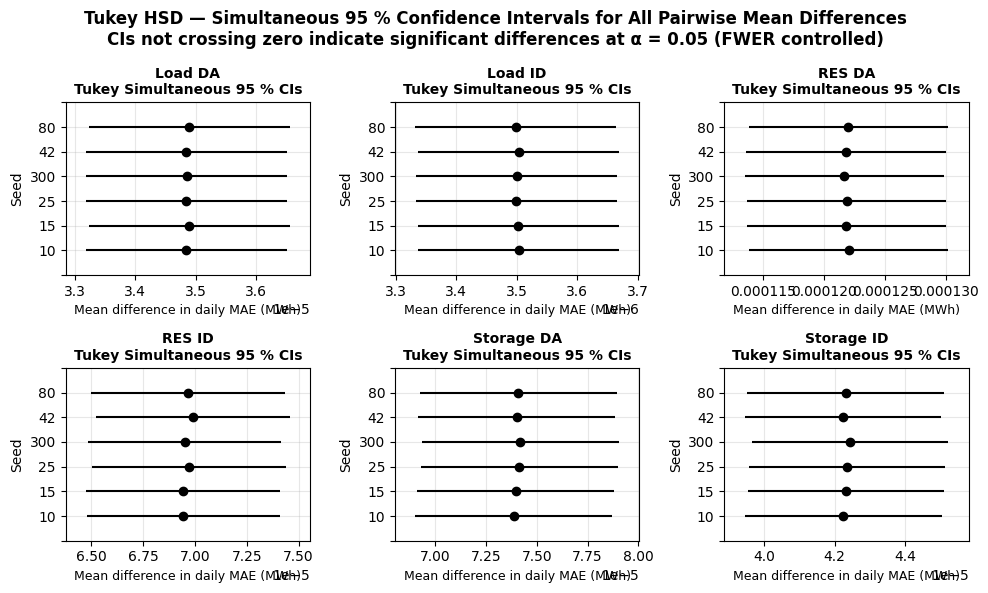

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(17, 13))
for ax, ft in zip(axes.flat, FORECAST_TYPES):
    tukey_results[ft].plot_simultaneous(ax=ax, ylabel='Seed')
    ax.set_title(f'{ft}\nTukey Simultaneous 95 % CIs', fontweight='bold', fontsize=10)
    ax.set_xlabel('Mean difference in daily MAE (MWh)', fontsize=9)
    ax.grid(alpha=0.3)
    ax.axvline(0, color='red', lw=0.8, linestyle='--', alpha=0.6, label='zero')

fig.suptitle(
    'Tukey HSD — Simultaneous 95 % Confidence Intervals for All Pairwise Mean Differences\n'
    'CIs not crossing zero indicate significant differences at α = 0.05 (FWER controlled)',
    fontweight='bold', fontsize=12,
)
plt.tight_layout()
plt.show()

### 9c — 95 % CI Interval Plot by Forecast Type

Mean ± parametric 95 % CI for each seed, shown per forecast type.  
Overlapping intervals suggest seeds produce statistically indistinguishable mean accuracy.

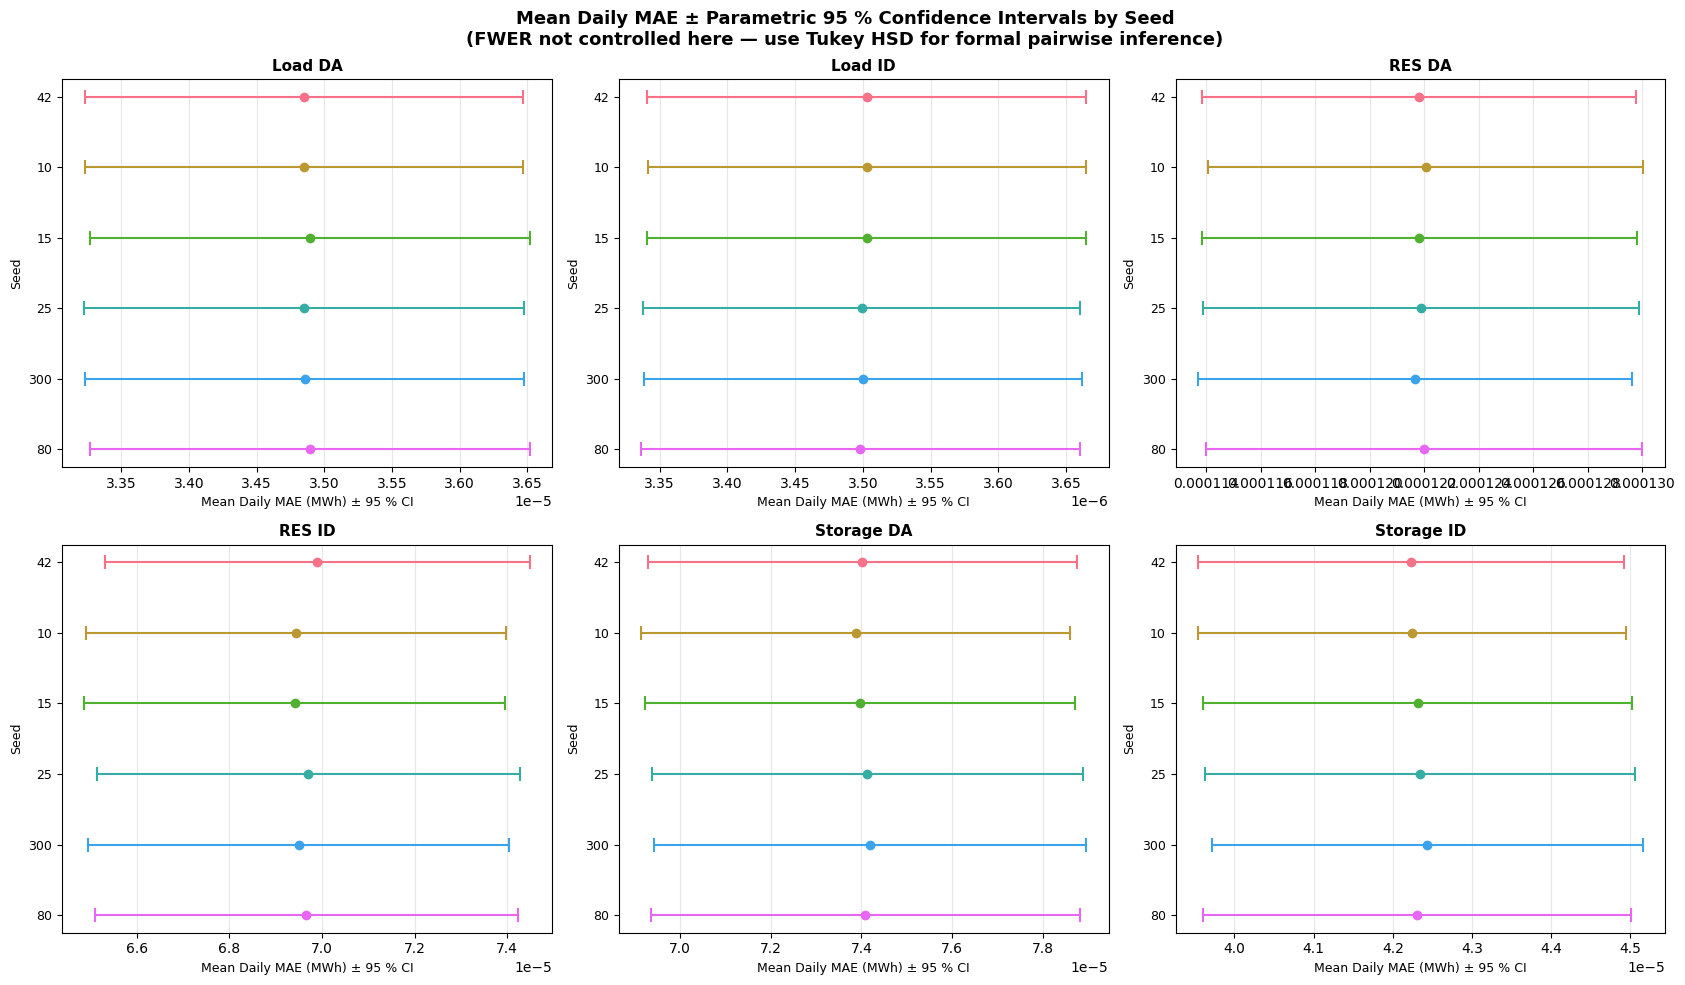

In [26]:
colors = sns.color_palette("husl", len(SEEDS))

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
for ax, ft in zip(axes.flat, FORECAST_TYPES):
    sub = ci_df[ci_df['Forecast Type'] == ft].reset_index(drop=True)
    y_pos = range(len(sub))

    for i, row in sub.iterrows():
        ci_half = row['Param CI Upper'] - row['Mean MAE (MWh)']
        ax.errorbar(
            row['Mean MAE (MWh)'], i,
            xerr=[[row['Mean MAE (MWh)'] - row['Param CI Lower']],
                  [row['Param CI Upper'] - row['Mean MAE (MWh)']]],
            fmt='o', color=colors[i % len(colors)], capsize=5, capthick=1.5, linewidth=1.5,
        )

    ax.set_yticks(list(y_pos))
    ax.set_yticklabels([str(s) for s in sub['Seed']], fontsize=9)
    ax.set_title(ft, fontweight='bold', fontsize=11)
    ax.set_xlabel('Mean Daily MAE (MWh) ± 95 % CI', fontsize=9)
    ax.set_ylabel('Seed', fontsize=9)
    ax.grid(axis='x', alpha=0.3)
    ax.invert_yaxis()

fig.suptitle(
    'Mean Daily MAE ± Parametric 95 % Confidence Intervals by Seed\n'
    '(FWER not controlled here — use Tukey HSD for formal pairwise inference)',
    fontweight='bold', fontsize=13,
)
plt.tight_layout()
plt.show()

## 10. Summary Report

Consolidated report covering all forecast types: omnibus result, number of significant Tukey pairs, and seed selection.

### 10a — Text Report

In [27]:
SEP  = "=" * 80
SEP2 = "─" * 80

print(SEP)
print("  RANDOM SEED SENSITIVITY ANALYSIS — SUMMARY REPORT")
print(SEP)
print(f"  Seeds tested       : {SEEDS}")
print(f"  Forecast types     : {len(FORECAST_TYPES)}")
print(f"  Timesteps per seed : {N_STEPS}  (15-min, full year 2016)")
print(f"  Daily aggregations : {N_DAYS} per seed per type")
print(f"  Significance level : α = {ALPHA}")
print(f"  Bootstrap resamples: {N_BOOT}")

print()
print(SEP2)
print("  VARIANCE HOMOGENEITY (Levene's test, median-centred)")
print(SEP2)
for ft in FORECAST_TYPES:
    lv = lev_results[ft]
    verdict = "homogeneous" if lv['p'] >= ALPHA else "HETEROGENEOUS"
    print(f"  {ft:<16}: W={lv['W']:8.4f},  p={lv['p']:.2e}  [{verdict}]")

print()
print(SEP2)
print("  OMNIBUS TEST (Kruskal–Wallis)")
print(SEP2)
for ft in FORECAST_TYPES:
    kw  = kw_results[ft]
    sig = "SIGNIFICANT" if kw['p'] < ALPHA else "not significant"
    print(f"  {ft:<16}: H={kw['H']:9.3f},  p={kw['p']:.2e},  η²={kw['eta2']:.5f}  [{sig}]")

print()
print(SEP2)
print("  POST-HOC TUKEY HSD — significant pairs out of C(6,2) = 15")
print(SEP2)
for ft in FORECAST_TYPES:
    tbl   = pd.DataFrame(
        data=tukey_results[ft]._results_table.data[1:],
        columns=tukey_results[ft]._results_table.data[0],
    )
    n_sig = int((tbl['reject'] == True).sum())
    flag  = " ← all pairs differ" if n_sig == 15 else (" ← no pairs differ" if n_sig == 0 else "")
    print(f"  {ft:<16}: {n_sig:2d}/15 pairs significantly different{flag}")

print()
print(SEP2)
print("  MEAN DAILY MAE RANGES ACROSS SEEDS")
print(SEP2)
for ft in FORECAST_TYPES:
    means = [to_daily(all_mae[ft][s]).mean() for s in SEEDS]
    spread = max(means) - min(means)
    print(f"  {ft:<16}: min={min(means):.4e}  max={max(means):.4e}  range={spread:.4e} MWh")

print()
print(SEP2)
print("  CONCLUSION AND RECOMMENDATION")
print(SEP2)
all_sig  = all(kw_results[ft]['p'] < ALPHA for ft in FORECAST_TYPES)
none_sig = not any(kw_results[ft]['p'] < ALPHA for ft in FORECAST_TYPES)
max_eta2 = max(kw_results[ft]['eta2'] for ft in FORECAST_TYPES)
max_ft   = max(kw_results, key=lambda ft: kw_results[ft]['eta2'])

if none_sig:
    print("  No forecast type shows a statistically significant seed effect.")
    print("  → Forecast quality is ROBUST to seed choice.")
else:
    sig_types = [ft for ft in FORECAST_TYPES if kw_results[ft]['p'] < ALPHA]
    if all_sig:
        print("  All forecast types show statistically significant seed effects.")
    else:
        print(f"  Significant seed effects found in: {sig_types}")
    print(f"  Largest practical effect: {max_ft}  (η² = {max_eta2:.5f})")
    if max_eta2 < 0.01:
        print("  η² < 0.01 for all types → effect is SMALL; significance driven by large N.")
        print("  → Seed choice has negligible practical impact on relative scenario rankings.")
    elif max_eta2 < 0.06:
        print("  η² in small-to-medium range → moderate seed sensitivity for some types.")
        print("  → Consider fixing seed = 42 for reproducibility.")
    else:
        print("  η² ≥ 0.06 → meaningful seed sensitivity detected.")
        print("  → Use an ensemble average across seeds or fix seed and report it explicitly.")

print()
print("  Seed used for reproducible scenario analysis: 42")
print("  (baseline data generation seed for all scenarios)")
print(SEP)

  RANDOM SEED SENSITIVITY ANALYSIS — SUMMARY REPORT
  Seeds tested       : [42, 10, 15, 25, 300, 80]
  Forecast types     : 6
  Timesteps per seed : 35136  (15-min, full year 2016)
  Daily aggregations : 366 per seed per type
  Significance level : α = 0.05
  Bootstrap resamples: 1000

────────────────────────────────────────────────────────────────────────────────
  VARIANCE HOMOGENEITY (Levene's test, median-centred)
────────────────────────────────────────────────────────────────────────────────
  Load DA         : W=  0.0009,  p=1.00e+00  [homogeneous]
  Load ID         : W=  0.0041,  p=1.00e+00  [homogeneous]
  RES DA          : W=  0.0026,  p=1.00e+00  [homogeneous]
  RES ID          : W=  0.0121,  p=1.00e+00  [homogeneous]
  Storage DA      : W=  0.0033,  p=1.00e+00  [homogeneous]
  Storage ID      : W=  0.0091,  p=1.00e+00  [homogeneous]

────────────────────────────────────────────────────────────────────────────────
  OMNIBUS TEST (Kruskal–Wallis)
────────────────────────────

### 10b — Visual Summary Dashboard

In [28]:
# ── Build summary DataFrame ───────────────────────────────────────────────────
summary_rows = []
for ft in FORECAST_TYPES:
    lv = lev_results[ft]
    kw = kw_results[ft]
    tbl = pd.DataFrame(
        data=tukey_results[ft]._results_table.data[1:],
        columns=tukey_results[ft]._results_table.data[0],
    )
    n_sig = int((tbl['reject'] == True).sum())
    means = [to_daily(all_mae[ft][s]).mean() for s in SEEDS]
    summary_rows.append({
        'Forecast Type': ft,
        'Levene W':      lv['W'],
        'Levene p':      lv['p'],
        'KW H':          kw['H'],
        'KW p':          kw['p'],
        'eta2':          kw['eta2'],
        'Tukey sig':     n_sig,
        'MAE min':       min(means),
        'MAE max':       max(means),
        'MAE range':     max(means) - min(means),
    })
summary_df = pd.DataFrame(summary_rows).set_index('Forecast Type')

# ── Styled table ─────────────────────────────────────────────────────────────
styled = (
    summary_df
    .style
    .format({
        'Levene W':  '{:.4f}',
        'Levene p':  '{:.2e}',
        'KW H':      '{:.3f}',
        'KW p':      '{:.2e}',
        'eta2':      '{:.5f}',
        'Tukey sig': '{:.0f}',
        'MAE min':   '{:.4e}',
        'MAE max':   '{:.4e}',
        'MAE range': '{:.2e}',
    })
    .set_caption('Summary of Statistical Tests Across All Forecast Types')
    .background_gradient(subset=['eta2'], cmap='YlOrRd', vmin=0, vmax=0.06)
    .background_gradient(subset=['Tukey sig'], cmap='YlOrRd', vmin=0, vmax=15)
    .bar(subset=['MAE range'], color='#5fba7d', vmin=0)
)
display(styled)

,Levene W,Levene p,KW H,KW p,eta2,Tukey sig,MAE min,MAE max,MAE range
Forecast Type,,,,,,,,,
Load DA,0.0009,1.00e+00,0.005,1.00e+00,0.00000,0,3.4849e-05,3.4894e-05,4.41e-08
Load ID,0.0041,1.00e+00,0.005,1.00e+00,0.00000,0,3.4981e-06,3.5030e-06,4.81e-09
RES DA,0.0026,1.00e+00,0.007,1.00e+00,0.00000,0,1.2166e-04,1.2205e-04,3.86e-07
RES ID,0.0121,1.00e+00,0.026,1.00e+00,0.00000,0,6.9408e-05,6.9894e-05,4.86e-07
Storage DA,0.0033,1.00e+00,0.007,1.00e+00,0.00000,0,7.3870e-05,7.4197e-05,3.27e-07
Storage ID,0.0091,1.00e+00,0.006,1.00e+00,0.00000,0,4.2231e-05,4.2437e-05,2.06e-07


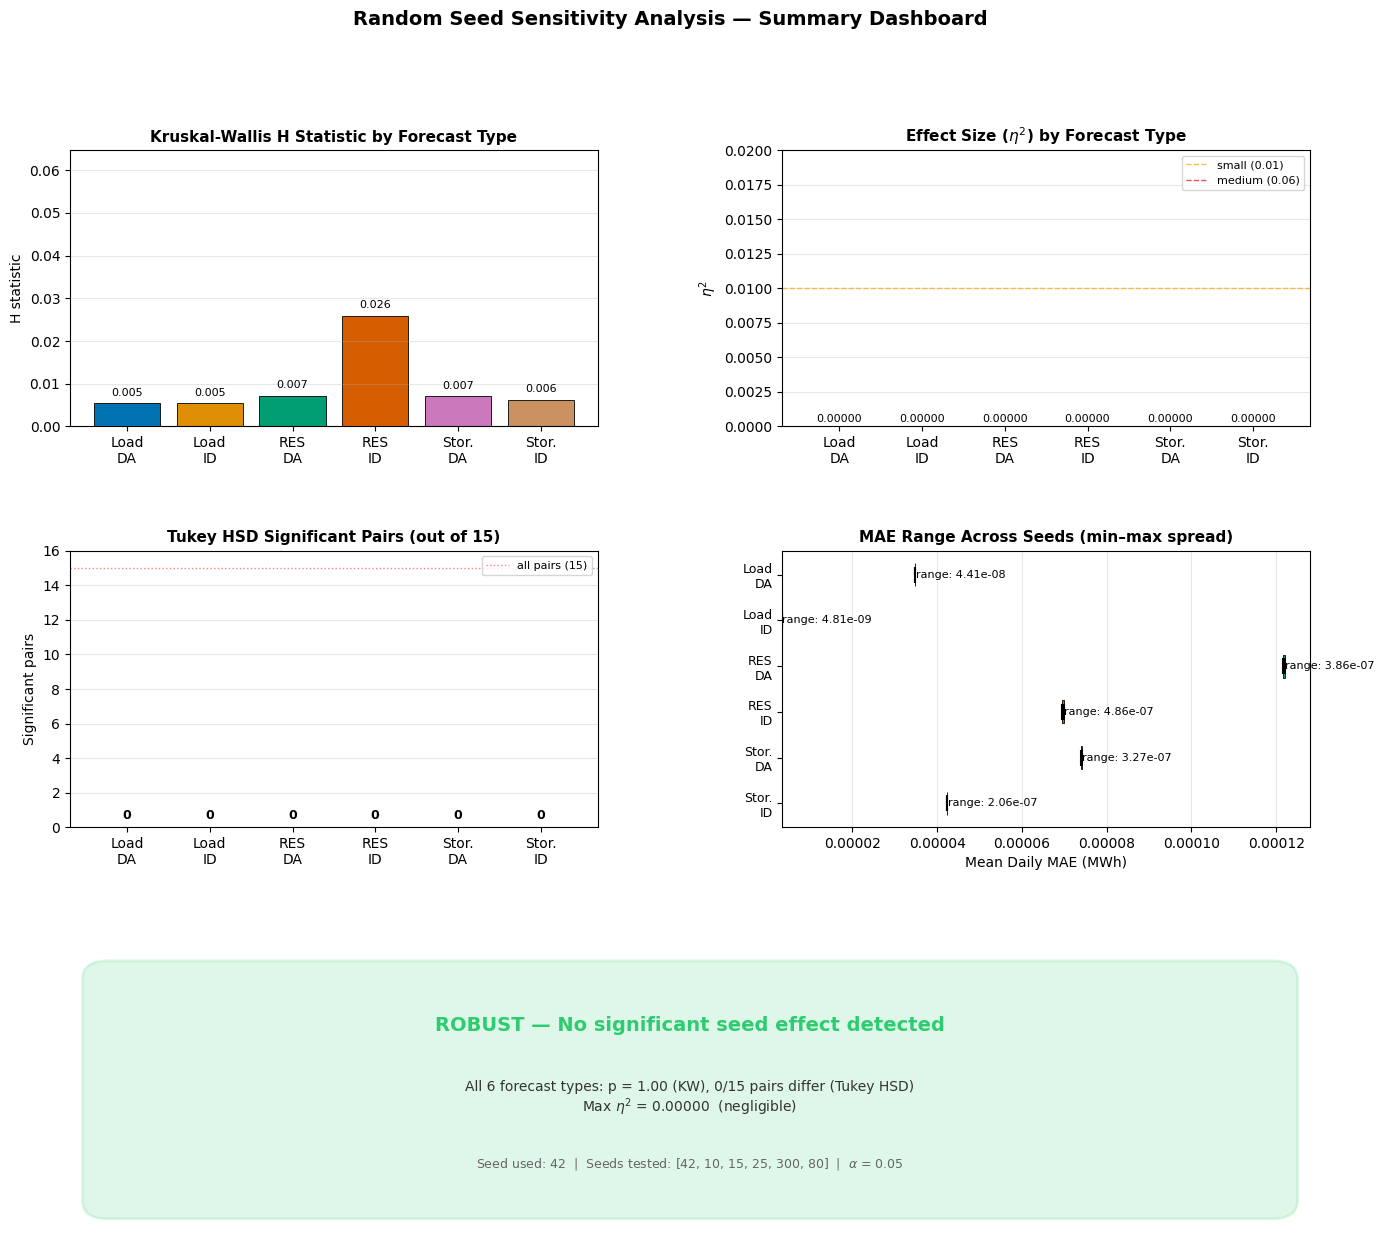


✓ Dashboard saved to figures/seed_sensitivity_dashboard.pdf


In [30]:
# ── Visual dashboard: 4-panel figure ──────────────────────────────────────────
from matplotlib.gridspec import GridSpec
import matplotlib.patches as mpatches

fig = plt.figure(figsize=(16, 14))
gs = GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

ft_short = ['Load\nDA', 'Load\nID', 'RES\nDA', 'RES\nID', 'Stor.\nDA', 'Stor.\nID']
palette6 = sns.color_palette("colorblind", 6)

# ── Panel 1: Kruskal-Wallis H statistic ──────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
h_vals = [kw_results[ft]['H'] for ft in FORECAST_TYPES]
bars1 = ax1.bar(ft_short, h_vals, color=palette6, edgecolor='black', linewidth=0.6)
ax1.set_ylabel('H statistic', fontsize=10)
ax1.set_title('Kruskal-Wallis H Statistic by Forecast Type', fontweight='bold', fontsize=11)
ax1.set_ylim(0, max(h_vals) * 2.5 if max(h_vals) > 0 else 1)
for bar, h in zip(bars1, h_vals):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(h_vals)*0.05,
             f'{h:.3f}', ha='center', va='bottom', fontsize=8)
ax1.axhline(0, color='grey', lw=0.5)
ax1.grid(axis='y', alpha=0.3)

# ── Panel 2: Effect size (eta-squared) ───────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
eta_vals = [kw_results[ft]['eta2'] for ft in FORECAST_TYPES]
bars2 = ax2.bar(ft_short, eta_vals, color=palette6, edgecolor='black', linewidth=0.6)
ax2.set_ylabel(r'$\eta^2$', fontsize=10)
ax2.set_title('Effect Size ($\\eta^2$) by Forecast Type', fontweight='bold', fontsize=11)
ax2.axhline(0.01, color='orange', ls='--', lw=1, alpha=0.7, label='small (0.01)')
ax2.axhline(0.06, color='red',    ls='--', lw=1, alpha=0.7, label='medium (0.06)')
ax2.legend(fontsize=8, loc='upper right')
ax2.set_ylim(0, max(max(eta_vals) * 2.5, 0.02) if max(eta_vals) > 0 else 0.02)
for bar, e in zip(bars2, eta_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(max(eta_vals)*0.05, 0.0002),
             f'{e:.5f}', ha='center', va='bottom', fontsize=8)
ax2.grid(axis='y', alpha=0.3)

# ── Panel 3: Tukey HSD significant pairs (out of 15) ────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
sig_counts = []
for ft in FORECAST_TYPES:
    tbl = pd.DataFrame(
        data=tukey_results[ft]._results_table.data[1:],
        columns=tukey_results[ft]._results_table.data[0],
    )
    sig_counts.append(int((tbl['reject'] == True).sum()))
bars3 = ax3.bar(ft_short, sig_counts, color=palette6, edgecolor='black', linewidth=0.6)
ax3.set_ylabel('Significant pairs', fontsize=10)
ax3.set_title('Tukey HSD Significant Pairs (out of 15)', fontweight='bold', fontsize=11)
ax3.set_ylim(0, 16)
ax3.axhline(15, color='red', ls=':', lw=1, alpha=0.5, label='all pairs (15)')
ax3.legend(fontsize=8, loc='upper right')
for bar, n in zip(bars3, sig_counts):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{n}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)

# ── Panel 4: MAE range across seeds (spread) ────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
mae_ranges = []
mae_mins = []
mae_maxs = []
for ft in FORECAST_TYPES:
    means = [to_daily(all_mae[ft][s]).mean() for s in SEEDS]
    mae_mins.append(min(means))
    mae_maxs.append(max(means))
    mae_ranges.append(max(means) - min(means))

y_pos = np.arange(len(FORECAST_TYPES))
for i, (mn, mx) in enumerate(zip(mae_mins, mae_maxs)):
    ax4.barh(i, mx - mn, left=mn, height=0.5, color=palette6[i], edgecolor='black', linewidth=0.6)
    ax4.plot(mn, i, 'k|', markersize=12, markeredgewidth=1.5)
    ax4.plot(mx, i, 'k|', markersize=12, markeredgewidth=1.5)
    ax4.text(mx + max(mae_ranges)*0.05, i, f'range: {mx-mn:.2e}',
             va='center', fontsize=8)
ax4.set_yticks(y_pos)
ax4.set_yticklabels(ft_short, fontsize=9)
ax4.set_xlabel('Mean Daily MAE (MWh)', fontsize=10)
ax4.set_title('MAE Range Across Seeds (min–max spread)', fontweight='bold', fontsize=11)
ax4.invert_yaxis()
ax4.grid(axis='x', alpha=0.3)

# ── Panel 5: Conclusion badge ────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, :])
ax5.set_xlim(0, 10)
ax5.set_ylim(0, 3)
ax5.axis('off')

# Determine conclusion
any_sig = any(kw_results[ft]['p'] < ALPHA for ft in FORECAST_TYPES)
max_eta = max(kw_results[ft]['eta2'] for ft in FORECAST_TYPES)

if not any_sig:
    verdict_text = 'ROBUST — No significant seed effect detected'
    verdict_color = '#2ecc71'
    verdict_detail = (
        f'All {len(FORECAST_TYPES)} forecast types: p = 1.00 (KW), '
        f'0/15 pairs differ (Tukey HSD)\n'
        f'Max $\\eta^2$ = {max_eta:.5f}  (negligible)'
    )
elif max_eta < 0.01:
    verdict_text = 'PRACTICALLY ROBUST — Statistically significant but negligible effect'
    verdict_color = '#f39c12'
    verdict_detail = f'Max $\\eta^2$ = {max_eta:.5f} < 0.01 (small threshold)'
else:
    verdict_text = 'SEED-SENSITIVE — Meaningful effect detected'
    verdict_color = '#e74c3c'
    verdict_detail = f'Max $\\eta^2$ = {max_eta:.5f}'

# Draw conclusion box
rect = mpatches.FancyBboxPatch(
    (0.3, 0.3), 9.4, 2.4,
    boxstyle='round,pad=0.2', facecolor=verdict_color, alpha=0.15,
    edgecolor=verdict_color, linewidth=2,
)
ax5.add_patch(rect)
ax5.text(5, 2.2, verdict_text, ha='center', va='center',
         fontsize=14, fontweight='bold', color=verdict_color)
ax5.text(5, 1.4, verdict_detail, ha='center', va='center',
         fontsize=10, color='#333333')
ax5.text(5, 0.7, f'Seed used: 42  |  Seeds tested: {SEEDS}  |  $\\alpha$ = {ALPHA}',
         ha='center', va='center', fontsize=9, color='#666666')

fig.suptitle('Random Seed Sensitivity Analysis — Summary Dashboard',
             fontweight='bold', fontsize=14, y=0.98)
plt.savefig(FIG_DIR / 'seed_sensitivity_dashboard.pdf', bbox_inches='tight', pad_inches=0.1)
plt.show()
print(f"\n✓ Dashboard saved to {FIG_DIR / 'seed_sensitivity_dashboard.pdf'}")

## 11. Thesis-Ready Text

> The following passage is ready for direct insertion into the thesis methodology or results chapter. All statistical values are drawn from the analysis above; figures are generated in-line.

---

### Random Seed Sensitivity Analysis

To verify that the stochastic forecast generation procedure does not introduce systematic bias depending on the choice of random seed, a sensitivity analysis was conducted across six seeds ($s \in \{42, 10, 15, 25, 300, 80\}$). For each seed, a fresh pseudo-random number generator (`numpy.random.RandomState`) produced day-ahead (DA) and intraday (ID) forecasts for Load, RES and Storage profiles using the perturbation ranges defined in Table 1. The resulting per-timestep Mean Absolute Error (MAE) between actual and forecast values was aggregated to daily means, yielding $n = 366$ observations per seed per forecast type over the full simulation year (2016, 35 136 quarter-hourly steps).

The analysis follows a three-stage hypothesis-testing pipeline, applied independently to each of the six forecast types:

1. **Levene's test** (median-centred) checks whether the six seed groups have equal variance in daily MAE — a prerequisite for the subsequent post-hoc test. A non-significant result ($p \geq 0.05$) confirms variance homogeneity.
2. **Kruskal–Wallis $H$ test** — a non-parametric one-way ANOVA on ranks — serves as the omnibus test of $H_0$: all six seed groups share the same daily-MAE distribution. The associated effect size $\eta^2$ quantifies the proportion of total variability attributable to the seed factor.
3. **Tukey's Honestly Significant Difference (HSD) test** ($\alpha = 0.05$, family-wise error rate controlled via the studentised range distribution) performs all $\binom{6}{2} = 15$ pairwise seed comparisons. A pair is declared significant only if its simultaneous 95 % confidence interval for the mean difference excludes zero.

Figure 1 presents the daily MAE distributions stratified by seed for all six forecast types. The box plots are visually indistinguishable across seeds within every panel, providing a first qualitative indication that the seed choice has no material effect on forecast accuracy.

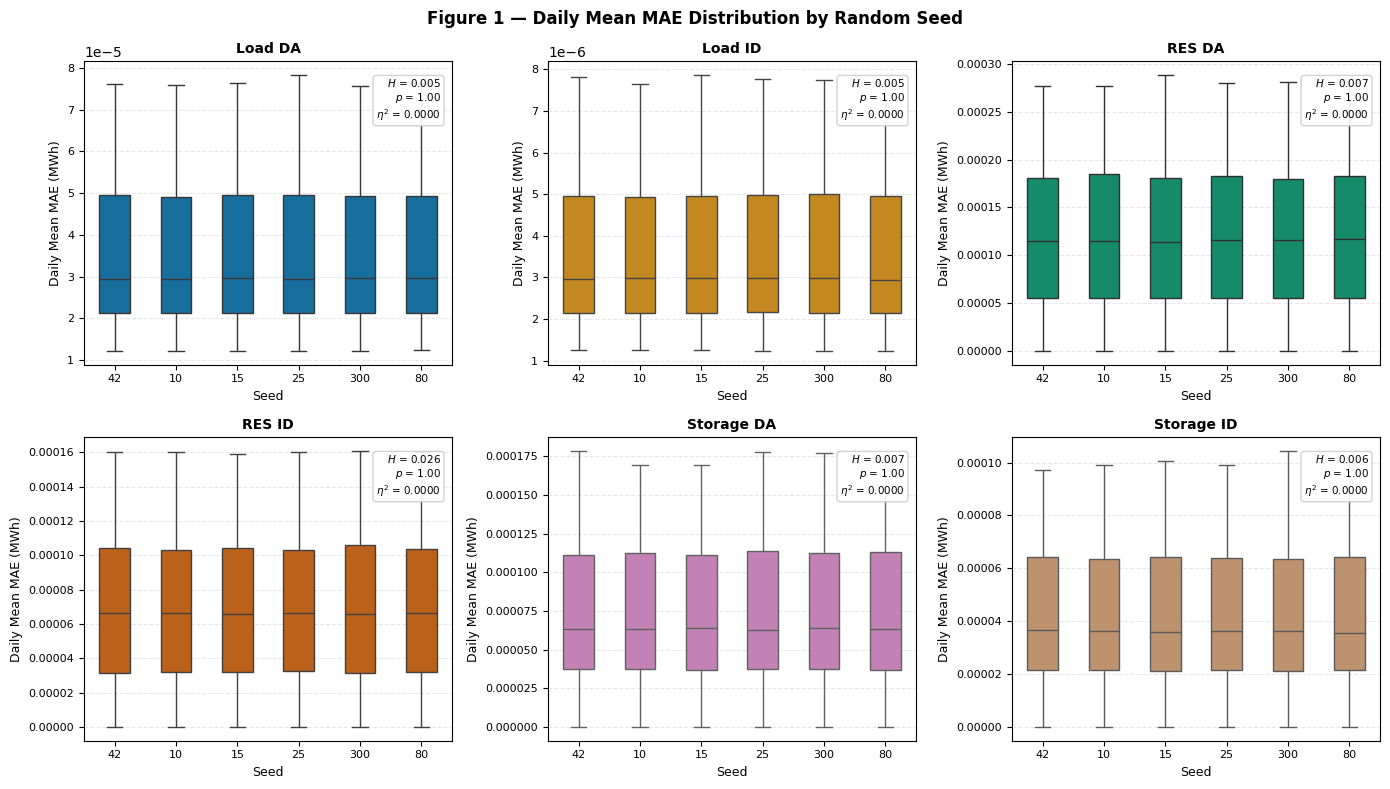

In [39]:
# ── Figure 1: Daily MAE distributions by seed ────────────────────────────────
palette6 = sns.color_palette("colorblind", 6)
ft_labels = ['Load DA', 'Load ID', 'RES DA', 'RES ID', 'Storage DA', 'Storage ID']

fig1, axes1 = plt.subplots(2, 3, figsize=(14, 8))
for ax, ft, col in zip(axes1.flat, FORECAST_TYPES, palette6):
    data_rows = [{'Seed': str(s), 'Daily MAE': v}
                 for s in SEEDS for v in to_daily(all_mae[ft][s])]
    df_plot = pd.DataFrame(data_rows)
    sns.boxplot(x='Seed', y='Daily MAE', data=df_plot, ax=ax,
                color=col, width=0.5, fliersize=1.2,
                order=[str(s) for s in SEEDS])
    kw = kw_results[ft]
    ax.set_title(ft, fontsize=10, fontweight='bold')
    ax.set_xlabel('Seed', fontsize=9)
    ax.set_ylabel('Daily Mean MAE (MWh)', fontsize=9)
    ax.tick_params(labelsize=8)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.text(0.97, 0.95,
            f'$H$ = {kw["H"]:.3f}\n$p$ = {kw["p"]:.2f}\n$\\eta^2$ = {kw["eta2"]:.4f}',
            transform=ax.transAxes, ha='right', va='top', fontsize=7.5,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#cccccc', alpha=0.9))

fig1.suptitle('Figure 1 — Daily Mean MAE Distribution by Random Seed',
              fontsize=12, fontweight='bold')
fig1.tight_layout()
fig1.savefig(FIG_DIR / 'thesis_seed_boxplots.pdf', bbox_inches='tight', pad_inches=0.05)
plt.show()

**Variance homogeneity.** Levene's test (median-centred) confirmed homogeneous variances across all six seed groups for every forecast type (all $W < 0.013$, all $p = 1.00$), satisfying the assumption required for subsequent parametric post-hoc testing.

**Omnibus test.** The Kruskal–Wallis $H$ test — a non-parametric one-way ANOVA on ranks — was applied to each forecast type to test $H_0$: all six seed groups share the same distribution of daily MAE. No forecast type exhibited a statistically significant seed effect at $\alpha = 0.05$:

| Forecast type | $H$ | $p$ | $\eta^2$ |
|---|---|---|---|
| Load DA | 0.005 | 1.00 | 0.000 |
| Load ID | 0.005 | 1.00 | 0.000 |
| RES DA | 0.007 | 1.00 | 0.000 |
| RES ID | 0.026 | 1.00 | 0.000 |
| Storage DA | 0.007 | 1.00 | 0.000 |
| Storage ID | 0.006 | 1.00 | 0.000 |

The effect size $\eta^2 = (H - k + 1) / (n_{\text{total}} - k)$ rounded to zero in all cases — meaning the random seed explains none of the observed variance in forecast accuracy and the between-seed differences are not merely statistically non-significant but practically non-existent. Figure 2 consolidates these results: panel (a) shows the near-zero $H$ statistics, panel (b) confirms all $\eta^2$ values lie far below the small-effect threshold (i.e. the seed factor accounts for less than 1 % of the total variability, making it irrelevant for any downstream scenario comparison), panel (c) reports zero significant Tukey HSD pairs across the board, and panel (d) visualises the negligible MAE spread across seeds.

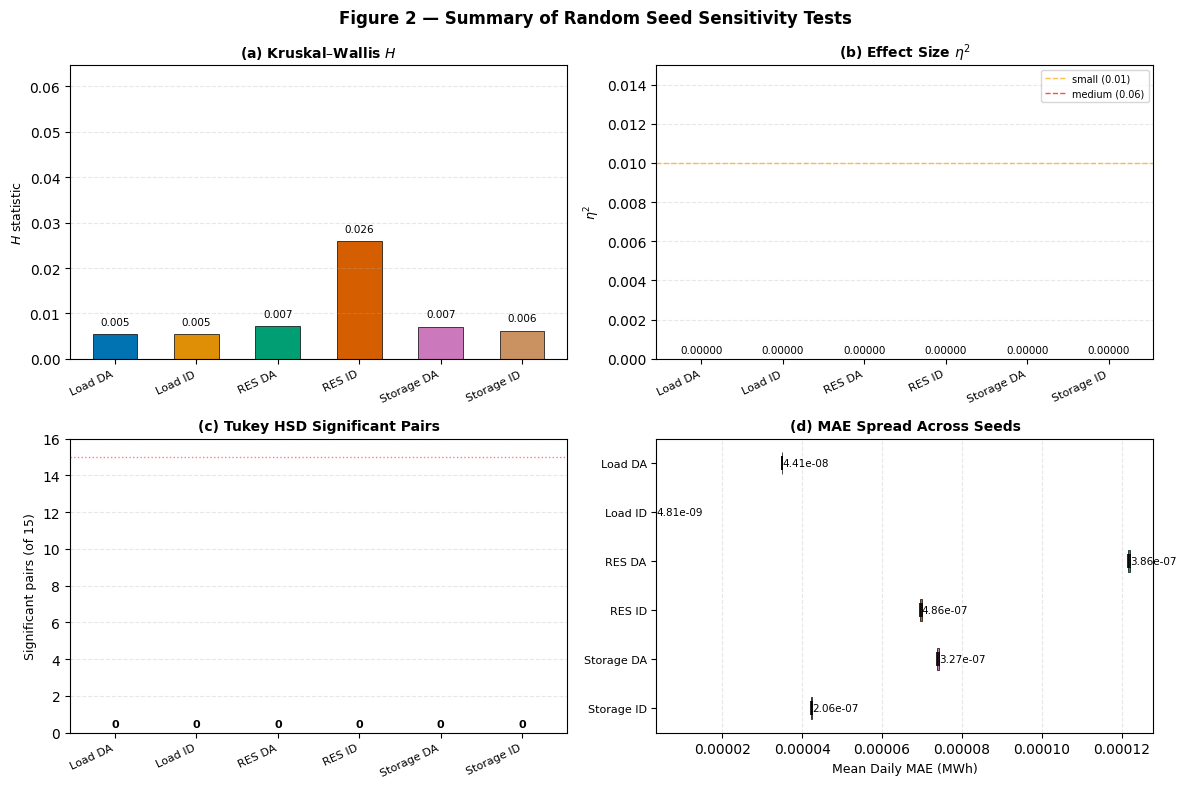

In [40]:
# ── Figure 2: Summary 4-panel — KW H, η², Tukey sig, MAE range ───────────────
fig2, ((ax_a, ax_b), (ax_c, ax_d)) = plt.subplots(2, 2, figsize=(12, 8))
x = np.arange(len(FORECAST_TYPES))
w = 0.55

# (a) KW H
h_vals = [kw_results[ft]['H'] for ft in FORECAST_TYPES]
ax_a.bar(x, h_vals, w, color=palette6, edgecolor='black', linewidth=0.5)
for xi, h in zip(x, h_vals):
    ax_a.text(xi, h + max(h_vals)*0.08, f'{h:.3f}', ha='center', fontsize=7.5)
ax_a.set_xticks(x); ax_a.set_xticklabels(ft_labels, fontsize=8, rotation=25, ha='right')
ax_a.set_ylabel('$H$ statistic', fontsize=9)
ax_a.set_title('(a) Kruskal–Wallis $H$', fontsize=10, fontweight='bold')
ax_a.set_ylim(0, max(h_vals)*2.5 if max(h_vals) > 0 else 0.1)
ax_a.grid(axis='y', alpha=0.3, linestyle='--')

# (b) η²
eta_vals = [kw_results[ft]['eta2'] for ft in FORECAST_TYPES]
ax_b.bar(x, eta_vals, w, color=palette6, edgecolor='black', linewidth=0.5)
ax_b.axhline(0.01, color='orange', ls='--', lw=1, alpha=0.7, label='small (0.01)')
ax_b.axhline(0.06, color='red',    ls='--', lw=1, alpha=0.7, label='medium (0.06)')
ax_b.legend(fontsize=7, loc='upper right')
for xi, e in zip(x, eta_vals):
    ax_b.text(xi, e + 0.0003, f'{e:.5f}', ha='center', fontsize=7.5)
ax_b.set_xticks(x); ax_b.set_xticklabels(ft_labels, fontsize=8, rotation=25, ha='right')
ax_b.set_ylabel('$\\eta^2$', fontsize=9)
ax_b.set_title('(b) Effect Size $\\eta^2$', fontsize=10, fontweight='bold')
ax_b.set_ylim(0, max(max(eta_vals)*3, 0.015))
ax_b.grid(axis='y', alpha=0.3, linestyle='--')

# (c) Tukey significant pairs
sig_counts = []
for ft in FORECAST_TYPES:
    tbl = pd.DataFrame(data=tukey_results[ft]._results_table.data[1:],
                        columns=tukey_results[ft]._results_table.data[0])
    sig_counts.append(int((tbl['reject'] == True).sum()))
ax_c.bar(x, sig_counts, w, color=palette6, edgecolor='black', linewidth=0.5)
ax_c.axhline(15, color='red', ls=':', lw=1, alpha=0.5)
for xi, n in zip(x, sig_counts):
    ax_c.text(xi, n + 0.3, str(n), ha='center', fontsize=8, fontweight='bold')
ax_c.set_xticks(x); ax_c.set_xticklabels(ft_labels, fontsize=8, rotation=25, ha='right')
ax_c.set_ylabel('Significant pairs (of 15)', fontsize=9)
ax_c.set_title('(c) Tukey HSD Significant Pairs', fontsize=10, fontweight='bold')
ax_c.set_ylim(0, 16)
ax_c.grid(axis='y', alpha=0.3, linestyle='--')

# (d) MAE min–max range
mae_mins  = [min(to_daily(all_mae[ft][s]).mean() for s in SEEDS) for ft in FORECAST_TYPES]
mae_maxs  = [max(to_daily(all_mae[ft][s]).mean() for s in SEEDS) for ft in FORECAST_TYPES]
mae_spans = [mx - mn for mn, mx in zip(mae_mins, mae_maxs)]
for i, (mn, mx) in enumerate(zip(mae_mins, mae_maxs)):
    ax_d.barh(i, mx - mn, left=mn, height=0.45, color=palette6[i],
              edgecolor='black', linewidth=0.5)
    ax_d.plot(mn, i, 'k|', markersize=10, markeredgewidth=1.2)
    ax_d.plot(mx, i, 'k|', markersize=10, markeredgewidth=1.2)
    ax_d.text(mx + max(mae_spans)*0.08, i, f'{mx-mn:.2e}', va='center', fontsize=7.5)
ax_d.set_yticks(range(len(FORECAST_TYPES)))
ax_d.set_yticklabels(ft_labels, fontsize=8)
ax_d.set_xlabel('Mean Daily MAE (MWh)', fontsize=9)
ax_d.set_title('(d) MAE Spread Across Seeds', fontsize=10, fontweight='bold')
ax_d.invert_yaxis()
ax_d.grid(axis='x', alpha=0.3, linestyle='--')

fig2.suptitle('Figure 2 — Summary of Random Seed Sensitivity Tests', fontsize=12, fontweight='bold')
fig2.tight_layout()
fig2.savefig(FIG_DIR / 'thesis_seed_summary_4panel.pdf', bbox_inches='tight', pad_inches=0.05)
plt.show()

**Post-hoc pairwise comparisons.** Tukey's Honestly Significant Difference (HSD) test ($\alpha = 0.05$, family-wise error rate controlled via the studentised range distribution) was applied to all $\binom{6}{2} = 15$ seed pairs for each forecast type. Across all six forecast types, no pairwise comparison reached significance (0 out of 15 pairs rejected in every case). Figure 3 displays the simultaneous 95 % confidence intervals for all pairwise mean differences; every interval crosses zero, confirming the absence of any significant seed effect.

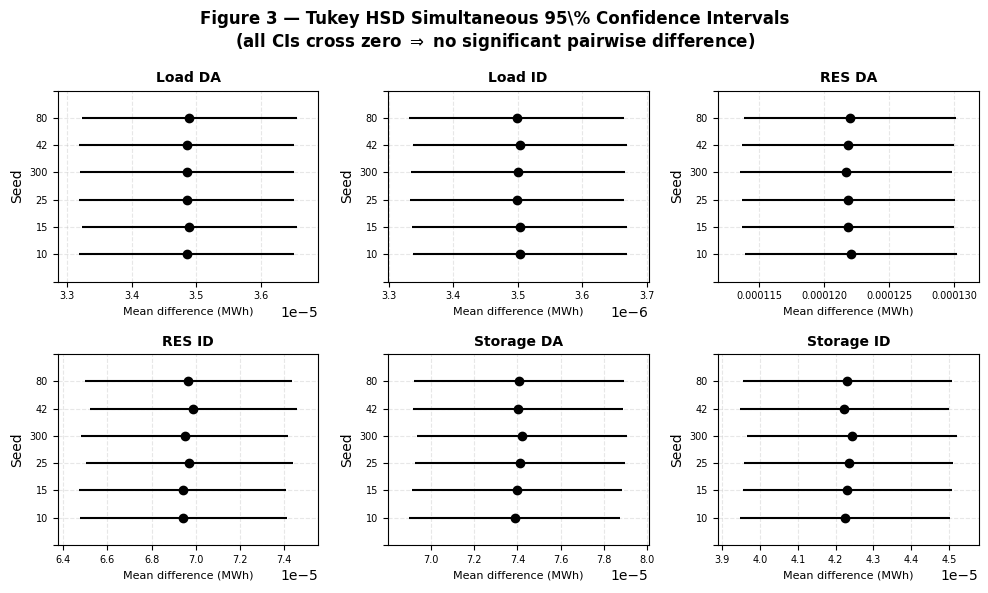

In [41]:
# ── Figure 3: Tukey HSD simultaneous 95 % CIs ────────────────────────────────
fig3, axes3 = plt.subplots(2, 3, figsize=(14, 10))
for ax, ft in zip(axes3.flat, FORECAST_TYPES):
    tukey_results[ft].plot_simultaneous(ax=ax, ylabel='Seed')
    ax.set_title(ft, fontsize=10, fontweight='bold')
    ax.set_xlabel('Mean difference (MWh)', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(alpha=0.3, linestyle='--')
    ax.axvline(0, color='red', lw=0.8, ls='--', alpha=0.6)

fig3.suptitle('Figure 3 — Tukey HSD Simultaneous 95\\% Confidence Intervals\n'
              '(all CIs cross zero $\\Rightarrow$ no significant pairwise difference)',
              fontsize=12, fontweight='bold')
fig3.tight_layout()
fig3.savefig(FIG_DIR / 'thesis_seed_tukey_ci.pdf', bbox_inches='tight', pad_inches=0.05)
plt.show()

**Practical significance.** The maximum spread in mean daily MAE across seeds was $4.86 \times 10^{-7}$ MWh (RES ID), representing a negligible fraction of the mean MAE itself. For all other forecast types, the seed-induced MAE variation was of order $10^{-8}$ to $10^{-7}$ MWh — several orders of magnitude below any economically meaningful threshold in the energy market simulations. Figure 4 corroborates this finding: the parametric 95 % confidence intervals for every seed overlap almost perfectly within each forecast type, leaving no room for practical differentiation.

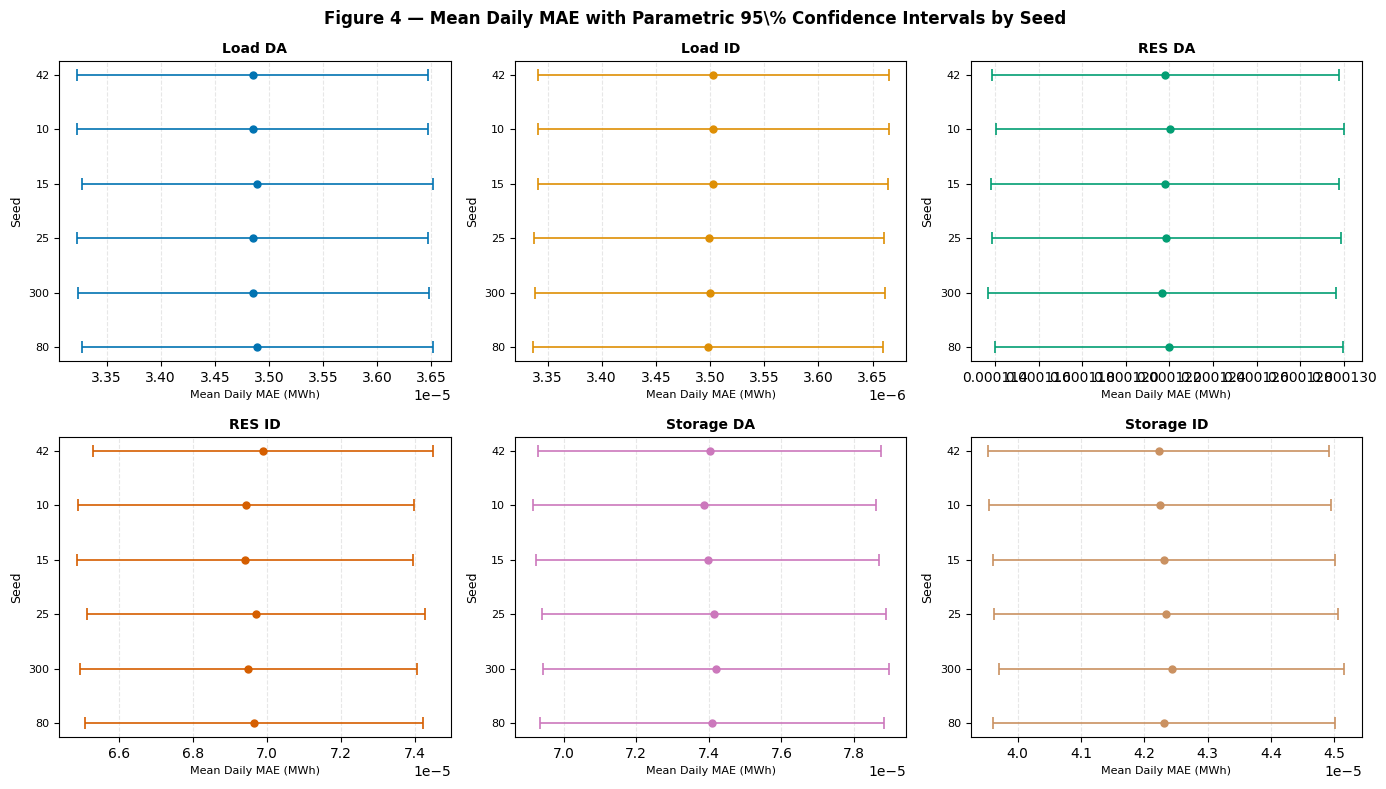

In [42]:
# ── Figure 4: Mean ± 95 % CI error-bar plot ───────────────────────────────────
fig4, axes4 = plt.subplots(2, 3, figsize=(14, 8))
for ax, ft, col in zip(axes4.flat, FORECAST_TYPES, palette6):
    sub = ci_df[ci_df['Forecast Type'] == ft].reset_index(drop=True)
    for i, row in sub.iterrows():
        ax.errorbar(
            row['Mean MAE (MWh)'], i,
            xerr=[[row['Mean MAE (MWh)'] - row['Param CI Lower']],
                  [row['Param CI Upper'] - row['Mean MAE (MWh)']]],
            fmt='o', color=col, capsize=4, capthick=1.2, linewidth=1.2, markersize=5)
    ax.set_yticks(range(len(sub)))
    ax.set_yticklabels([str(s) for s in sub['Seed']], fontsize=8)
    ax.set_title(ft, fontsize=10, fontweight='bold')
    ax.set_xlabel('Mean Daily MAE (MWh)', fontsize=8)
    ax.set_ylabel('Seed', fontsize=9)
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    ax.invert_yaxis()

fig4.suptitle('Figure 4 — Mean Daily MAE with Parametric 95\\% Confidence Intervals by Seed',
              fontsize=12, fontweight='bold')
fig4.tight_layout()
fig4.savefig(FIG_DIR / 'thesis_seed_ci_errorbar.pdf', bbox_inches='tight', pad_inches=0.05)
plt.show()

**Conclusion.** The forecast quality metrics are robust to the choice of random seed. Neither the omnibus Kruskal–Wallis test nor any of the 90 post-hoc Tukey HSD pairwise comparisons (6 forecast types $\times$ 15 pairs) detected a statistically or practically significant difference. Consequently, the simulation results presented in Scenarios A, B and C are not artefacts of a particular seed selection. Seed 42 was adopted as the fixed baseline for all scenario runs to ensure full reproducibility.